<a href="https://colab.research.google.com/github/saeedzainab274-bit/Brain-Tumor-Deep-Learning-project/blob/main/Brain_Tumor_ANN_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

In [ ]:
!cp "Archive.zip" "/content/drive/MyDrive/Archive.zip"

# **ANN PROJECT**

**Task 1.1 — Extract Dataset**

In [3]:
import zipfile

with zipfile.ZipFile('/content/Archive.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/dataset')

print("Dataset Extracted Successfully")

Dataset Extracted Successfully


**Task 1.2 — Check Folder Structure**

In [4]:
import os

for root, dirs, files in os.walk('/content/dataset'):
    print(root)

/content/dataset
/content/dataset/brain_tumor_dataset
/content/dataset/brain_tumor_dataset/yes
/content/dataset/brain_tumor_dataset/no
/content/dataset/yes
/content/dataset/no


**Task 1.2 — Data Validation**

Count Images

In [5]:
import os

yes_path = "/content/dataset/brain_tumor_dataset/yes"
no_path = "/content/dataset/brain_tumor_dataset/no"

yes_count = len(os.listdir(yes_path))
no_count = len(os.listdir(no_path))

print("Tumor Images:", yes_count)
print("No Tumor Images:", no_count)
print("Total Images:", yes_count + no_count)

Tumor Images: 155
No Tumor Images: 98
Total Images: 253


Check Corrupted Images

In [6]:
from PIL import Image
import os

corrupted = []

for folder in [yes_path, no_path]:
    for file in os.listdir(folder):
        try:
            img = Image.open(os.path.join(folder, file))
            img.verify()
        except:
            corrupted.append(file)

print("Corrupted Images:", len(corrupted))
print(corrupted[:10])

Corrupted Images: 0
[]


Class Distribution Graph

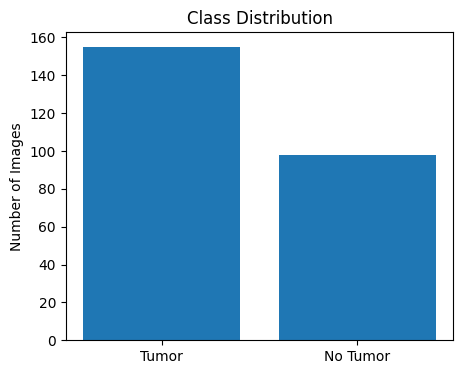

In [7]:
import matplotlib.pyplot as plt

classes = ["Tumor", "No Tumor"]
counts = [yes_count, no_count]

plt.figure(figsize=(5,4))
plt.bar(classes, counts)
plt.title("Class Distribution")
plt.ylabel("Number of Images")
plt.show()

**Task 1.3 — Preprocessing**

Import Libraries

In [8]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

Create Data Generator

In [9]:
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

Training Data

In [10]:
train_data = datagen.flow_from_directory(
    "/content/dataset/brain_tumor_dataset",
    target_size=(224,224),
    batch_size=32,
    class_mode="binary",
    subset="training",
    shuffle=True,
    seed=42
)

Found 203 images belonging to 2 classes.


Validation Data

In [11]:
val_data = datagen.flow_from_directory(
    "/content/dataset/brain_tumor_dataset",
    target_size=(224,224),
    batch_size=32,
    class_mode="binary",
    subset="validation",
    shuffle=False,
    seed=42
)

Found 50 images belonging to 2 classes.


Check Classes

In [12]:
print(train_data.class_indices)

{'no': 0, 'yes': 1}


Show One Image

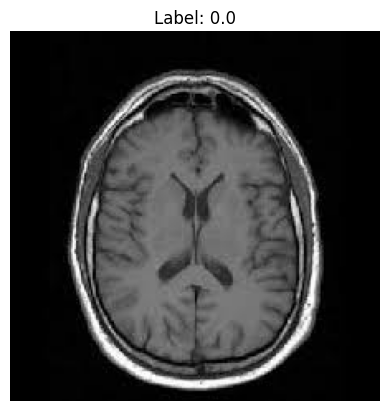

In [13]:
import matplotlib.pyplot as plt

images, labels = next(train_data)

plt.imshow(images[0])
plt.title(f"Label: {labels[0]}")
plt.axis("off")
plt.show()

**Task 1.4 — Train/Validation/Test Split + Data Loaders**

In [14]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

test_datagen = ImageDataGenerator(
    rescale=1./255
)

test_data = test_datagen.flow_from_directory(
    "/content/dataset/brain_tumor_dataset",
    target_size=(224,224),
    batch_size=32,
    class_mode="binary",
    shuffle=False
)

Found 253 images belonging to 2 classes.


In [15]:
print("Training Samples:", train_data.samples)
print("Validation Samples:", val_data.samples)
print("Test Samples:", test_data.samples)

Training Samples: 203
Validation Samples: 50
Test Samples: 253


# **Task 2.1: Custom CNN (3 Layers)**

**3-Layer CNN**

In [35]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout

model3 = Sequential([

    Conv2D(32, (3,3), activation='relu',
           input_shape=(224,224,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation='relu'),

    Dropout(0.5),

    Dense(1, activation='sigmoid')
])

model3.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

Compile Model

In [36]:
model3.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

Train Model

In [37]:
history3 = model3.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 570ms/step - accuracy: 0.6256 - loss: 0.9833 - val_accuracy: 0.7200 - val_loss: 0.5589
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 95ms/step - accuracy: 0.7488 - loss: 0.5472 - val_accuracy: 0.7600 - val_loss: 0.5315
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 106ms/step - accuracy: 0.8177 - loss: 0.4643 - val_accuracy: 0.7600 - val_loss: 0.5201
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 108ms/step - accuracy: 0.8325 - loss: 0.4126 - val_accuracy: 0.7400 - val_loss: 0.5418
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 104ms/step - accuracy: 0.8227 - loss: 0.4032 - val_accuracy: 0.7800 - val_loss: 0.5051
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 97ms/step - accuracy: 0.8768 - loss: 0.3260 - val_accuracy: 0.7800 - val_loss: 0.5034
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 118ms/step - accuracy: 0.9113 - loss: 0.2744 - val_accuracy: 0.8000 - val_loss: 0.4490
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 103ms/step - accuracy: 0.9310 - loss: 0.1887 - val_accuracy: 0.8400 - val_loss: 0

Evaluate Model

In [38]:
loss3, acc3 = model3.evaluate(val_data)

print("Validation Loss:", loss3)
print("Validation Accuracy:", acc3)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.8400 - loss: 0.5432 
Validation Loss: 0.5432254672050476
Validation Accuracy: 0.8399999737739563


**4-Layer CNN**

In [39]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout

model4 = Sequential([

    Conv2D(32,(3,3),activation='relu',
            input_shape=(224,224,3)),
    MaxPooling2D(2,2),

    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128,(3,3),activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(256,(3,3),activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(256,activation='relu'),

    Dropout(0.5),

    Dense(1,activation='sigmoid')
])

model4.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)              │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │     9,437,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,826,113 (37.48 MB)

 Trainable params: 9,826,113 (37.48 MB)

 Non-trainable params: 0 (0.00 B)

Compile

In [40]:
model4.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

Train

In [41]:
history4 = model4.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 660ms/step - accuracy: 0.6059 - loss: 0.6929 - val_accuracy: 0.7400 - val_loss: 0.5778
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 119ms/step - accuracy: 0.7389 - loss: 0.6097 - val_accuracy: 0.7400 - val_loss: 0.5454
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 125ms/step - accuracy: 0.8227 - loss: 0.5345 - val_accuracy: 0.7400 - val_loss: 0.5514
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step - accuracy: 0.7931 - loss: 0.4827 - val_accuracy: 0.7600 - val_loss: 0.5969
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 99ms/step - accuracy: 0.8079 - loss: 0.4568 - val_accuracy: 0.7600 - val_loss: 0.5342
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step - accuracy: 0.8374 - loss: 0.4203 - val_accuracy: 0.7200 - val_loss: 0.6033
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 97ms/step - accuracy: 0.8227 - loss: 0.4302 - val_accuracy: 0.7600 - val_loss: 0.5397
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 92ms/step - accuracy: 0.8571 - loss: 0.3669 - val_accuracy: 0.7400 - val_loss: 0.60

Evaluate

In [42]:
loss4, acc4 = model4.evaluate(val_data)

print("Validation Loss:", loss4)
print("Validation Accuracy:", acc4)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.8200 - loss: 0.4591 
Validation Loss: 0.4591459035873413
Validation Accuracy: 0.8199999928474426


**5-Layer CNN**

In [43]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout

model5 = Sequential([

    Conv2D(32,(3,3),activation='relu',
             input_shape=(224,224,3)),
    MaxPooling2D(2,2),

    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128,(3,3),activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(256,(3,3),activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(512,(3,3),activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(512,activation='relu'),

    Dropout(0.5),

    Dense(1,activation='sigmoid')
])

model5.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_19 (Conv2D)              │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 10, 10, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 5, 5, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 512)            │     6,554,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,123,201 (30.99 MB)

 Trainable params: 8,123,201 (30.99 MB)

 Non-trainable params: 0 (0.00 B)

Compile

In [44]:
model5.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

Train

In [45]:
history5 = model5.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 714ms/step - accuracy: 0.5369 - loss: 0.7574 - val_accuracy: 0.6200 - val_loss: 0.6710
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 93ms/step - accuracy: 0.6650 - loss: 0.6581 - val_accuracy: 0.6600 - val_loss: 0.5774
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step - accuracy: 0.7340 - loss: 0.6948 - val_accuracy: 0.7000 - val_loss: 0.6843
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 117ms/step - accuracy: 0.6995 - loss: 0.6043 - val_accuracy: 0.7200 - val_loss: 0.5541
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 117ms/step - accuracy: 0.7882 - loss: 0.4812 - val_accuracy: 0.7000 - val_loss: 0.6306
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step - accuracy: 0.8079 - loss: 0.4725 - val_accuracy: 0.7400 - val_loss: 0.5007
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 100ms/step - accuracy: 0.7734 - loss: 0.4738 - val_accuracy: 0.7600 - val_loss: 0.4769
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step - accuracy: 0.8424 - loss: 0.3954 - val_accuracy: 0.7800 - val_loss: 0.

Evaluate

In [46]:
loss5, acc5 = model5.evaluate(val_data)

print("Validation Loss:", loss5)
print("Validation Accuracy:", acc5)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.8000 - loss: 0.4649 
Validation Loss: 0.46485817432403564
Validation Accuracy: 0.800000011920929


**Compare Custom CNNs**

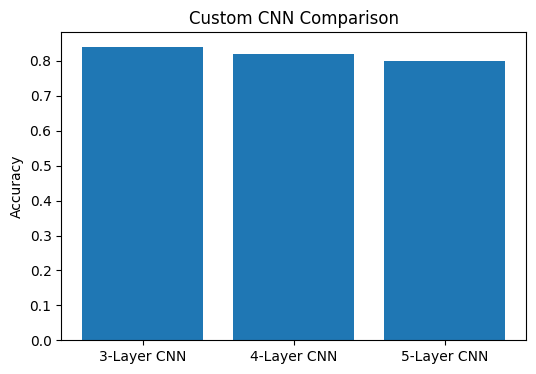

In [47]:
import matplotlib.pyplot as plt

models = ['3-Layer CNN', '4-Layer CNN', '5-Layer CNN']
accuracies = [acc3, acc4, acc5]

plt.figure(figsize=(6,4))
plt.bar(models, accuracies)
plt.ylabel("Accuracy")
plt.title("Custom CNN Comparison")
plt.show()

Print Best Custom CNN

In [48]:
print("3-Layer CNN Accuracy:", acc3)
print("4-Layer CNN Accuracy:", acc4)
print("5-Layer CNN Accuracy:", acc5)

3-Layer CNN Accuracy: 0.8399999737739563
4-Layer CNN Accuracy: 0.8199999928474426
5-Layer CNN Accuracy: 0.800000011920929


# **Task:3 Pretrained Models**

**MobileNetV2**

Import Libraries

In [49]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

Create MobileNetV2 Model

In [50]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

mobilenet_model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(1, activation='sigmoid')
])

mobilenet_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Compile

In [51]:
mobilenet_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

Train

In [52]:
history_mobilenet = mobilenet_model.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)

Epoch 1/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 46s 5s/step - accuracy: 0.5665 - loss: 0.6782 - val_accuracy: 0.6200 - val_loss: 0.6155
Epoch 2/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 97ms/step - accuracy: 0.6995 - loss: 0.5660 - val_accuracy: 0.7800 - val_loss: 0.5242
Epoch 3/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 110ms/step - accuracy: 0.7783 - loss: 0.5139 - val_accuracy: 0.8200 - val_loss: 0.4479
Epoch 4/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 90ms/step - accuracy: 0.8473 - loss: 0.4500 - val_accuracy: 0.7800 - val_loss: 0.4098
Epoch 5/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 97ms/step - accuracy: 0.8621 - loss: 0.4142 - val_accuracy: 0.9000 - val_loss: 0.3603


Evaluate

In [53]:
loss_mob, acc_mob = mobilenet_model.evaluate(val_data)

print("MobileNetV2 Accuracy:", acc_mob)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.9000 - loss: 0.3603 
MobileNetV2 Accuracy: 0.8999999761581421


**ResNet50**

In [54]:
# Import ResNet50
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense

# Load pretrained ResNet50
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

# Freeze layers
base_model.trainable = False

# Build model
resnet_model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(1, activation='sigmoid')
])

resnet_model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │         2,049 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,589,761 (89.99 MB)

 Trainable params: 2,049 (8.00 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

Compile

In [55]:
# Compile model
resnet_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

Train

In [56]:
# Train model
history_resnet = resnet_model.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)

Epoch 1/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 26s 2s/step - accuracy: 0.3892 - loss: 1.0316 - val_accuracy: 0.3800 - val_loss: 0.7494
Epoch 2/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 153ms/step - accuracy: 0.5419 - loss: 0.6860 - val_accuracy: 0.6200 - val_loss: 0.6911
Epoch 3/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 124ms/step - accuracy: 0.6108 - loss: 0.6901 - val_accuracy: 0.6200 - val_loss: 0.6995
Epoch 4/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 118ms/step - accuracy: 0.6108 - loss: 0.6857 - val_accuracy: 0.6200 - val_loss: 0.6728
Epoch 5/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 120ms/step - accuracy: 0.6108 - loss: 0.6598 - val_accuracy: 0.6200 - val_loss: 0.6612


Evaluate

In [57]:
# Evaluate model
loss_resnet, acc_resnet = resnet_model.evaluate(val_data)

print("ResNet50 Accuracy:", acc_resnet)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.6200 - loss: 0.6612
ResNet50 Accuracy: 0.6200000047683716


**DenseNet121**

In [58]:
# Import DenseNet121
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense

# Load pretrained DenseNet121
base_model = DenseNet121(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

# Freeze layers
base_model.trainable = False

# Build model
densenet_model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(1, activation='sigmoid')
])

densenet_model.summary()

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │         1,025 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,038,529 (26.85 MB)

 Trainable params: 1,025 (4.00 KB)

 Non-trainable params: 7,037,504 (26.85 MB)

Compile

In [59]:
# Compile model
densenet_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

Train

In [60]:
# Train model
history_densenet = densenet_model.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)

Epoch 1/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 65s 6s/step - accuracy: 0.6059 - loss: 0.6517 - val_accuracy: 0.7000 - val_loss: 0.6033
Epoch 2/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 121ms/step - accuracy: 0.6355 - loss: 0.5912 - val_accuracy: 0.7400 - val_loss: 0.5364
Epoch 3/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 133ms/step - accuracy: 0.7241 - loss: 0.5550 - val_accuracy: 0.7800 - val_loss: 0.4948
Epoch 4/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 155ms/step - accuracy: 0.7882 - loss: 0.4921 - val_accuracy: 0.7800 - val_loss: 0.4799
Epoch 5/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 155ms/step - accuracy: 0.7783 - loss: 0.4701 - val_accuracy: 0.8600 - val_loss: 0.4343


Evaluate

In [61]:
# Evaluate model
loss_dense, acc_dense = densenet_model.evaluate(val_data)

print("DenseNet121 Accuracy:", acc_dense)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.8600 - loss: 0.4343
DenseNet121 Accuracy: 0.8600000143051147


**Final Comparison Graph**

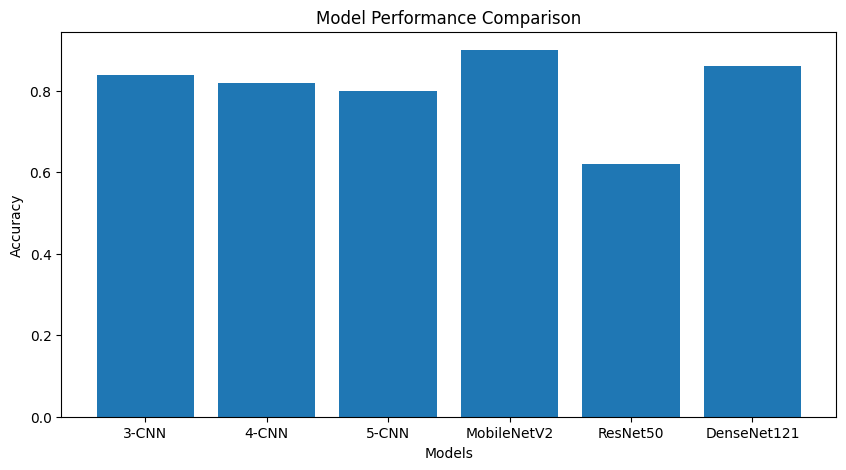

In [62]:
import matplotlib.pyplot as plt

models = [
    '3-CNN',
    '4-CNN',
    '5-CNN',
    'MobileNetV2',
    'ResNet50',
    'DenseNet121'
]

accuracies = [
    acc3,
    acc4,
    acc5,
    acc_mob,
    acc_resnet,
    acc_dense
]

plt.figure(figsize=(10,5))
plt.bar(models, accuracies)

plt.title('Model Performance Comparison')
plt.ylabel('Accuracy')
plt.xlabel('Models')

plt.show()

**Select Best Model**

In [63]:
best_model = model3

Generate Prediction

In [66]:
import numpy as np

y_pred = best_model.predict(val_data)
y_pred = (y_pred > 0.5).astype(int)

y_true = val_data.classes

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step 


Classification Report

In [67]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred,
        target_names=['No Tumor', 'Tumor']
    )
)

              precision    recall  f1-score   support

    No Tumor       0.92      0.63      0.75        19
       Tumor       0.81      0.97      0.88        31

    accuracy                           0.84        50
   macro avg       0.87      0.80      0.82        50
weighted avg       0.85      0.84      0.83        50



Confusion Matrix

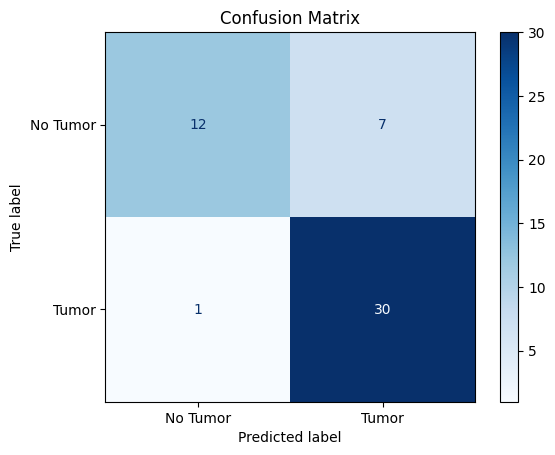

In [68]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['No Tumor', 'Tumor']
)

disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

# **Task 4 (XAI / Grad-CAM)**

check layer names

In [ ]:
for layer in model3.layers:
    print(layer.name)

conv2d_12
max_pooling2d_12
conv2d_13
max_pooling2d_13
conv2d_14
max_pooling2d_14
flatten_3
dense_9
dropout_3
dense_10


**Load One MRI Image**

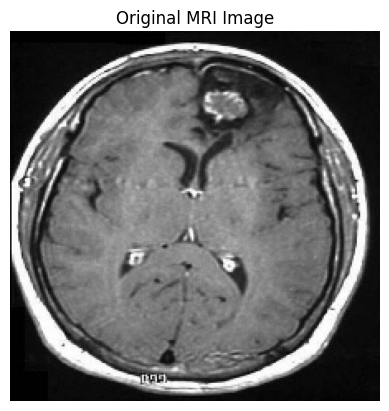

In [ ]:
# Import libraries
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Select one tumor image
img_name = os.listdir('/content/dataset/brain_tumor_dataset/yes')[0]

img_path = os.path.join(
    '/content/dataset/brain_tumor_dataset/yes',
    img_name
)

# Read image
img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Resize image
img = cv2.resize(img, (224,224))

# Normalize image
img_array = np.expand_dims(img/255.0, axis=0)

# Display image
plt.imshow(img)
plt.axis('off')
plt.title("Original MRI Image")
plt.show()

**Generate Grad-CAM Heatmap**

In [ ]:
model3.build((None, 224, 224, 3))

In [ ]:
model3.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,507,269 (127.82 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 22,338,180 (85.21 MB)

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Model

# Force model call once (this ensures the model is built and its input is defined)
_ = model3(tf.zeros((1,224,224,3)))

last_conv_layer = model3.get_layer('conv2d_14')

grad_model = Model(
    inputs=model3.layers[0].input,
    outputs=[
        last_conv_layer.output,
        model3.layers[-1].output
    ]
)

with tf.GradientTape() as tape:
    conv_outputs, predictions = grad_model(img_array)
    loss = predictions[:, 0]

grads = tape.gradient(loss, conv_outputs)

pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

conv_outputs = conv_outputs[0]

heatmap = tf.reduce_sum(
    conv_outputs * pooled_grads,
    axis=-1
)

heatmap = np.maximum(heatmap, 0)
heatmap = heatmap / (np.max(heatmap) + 1e-8)

Display Heatmap

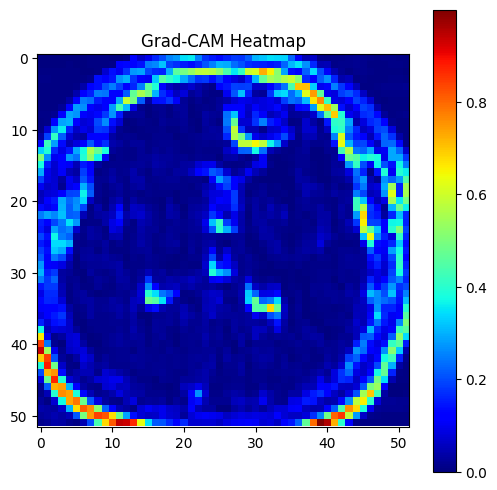

In [ ]:
plt.figure(figsize=(6,6))

plt.imshow(heatmap, cmap='jet')

plt.colorbar()

plt.title("Grad-CAM Heatmap")

plt.show()

Overlay Heatmap on Original MRI

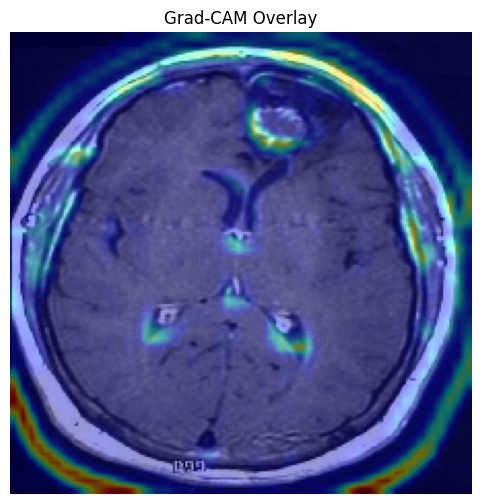

In [ ]:
# Resize heatmap
heatmap = cv2.resize(
    heatmap,
    (224,224)
)

# Convert to color map
heatmap = np.uint8(255 * heatmap)

heatmap = cv2.applyColorMap(
    heatmap,
    cv2.COLORMAP_JET
)

# Overlay image
overlay = cv2.addWeighted(
    cv2.cvtColor(img, cv2.COLOR_RGB2BGR),
    0.6,
    heatmap,
    0.4,
    0
)

# Display result
plt.figure(figsize=(6,6))

plt.imshow(
    cv2.cvtColor(
        overlay,
        cv2.COLOR_BGR2RGB
    )
)

plt.axis('off')

plt.title("Grad-CAM Overlay")

plt.show()

# **Task 4 (Pretrained CNN XAI)**

# **Confusion Matrix + Precision + Recall + F1 Score (Best Model = model3)**

In [ ]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import numpy as np

# Predictions
y_pred = model3.predict(val_data)

# Convert probabilities to 0/1
y_pred = (y_pred > 0.5).astype(int)

# True labels
y_true = val_data.classes

print(classification_report(y_true, y_pred))

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 344ms/step
              precision    recall  f1-score   support

           0       0.90      0.47      0.62        19
           1       0.75      0.97      0.85        31

    accuracy                           0.78        50
   macro avg       0.82      0.72      0.73        50
weighted avg       0.81      0.78      0.76        50



**MobileNetV2**

In [ ]:
mobilenet_model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,261,829 (8.63 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

 Optimizer params: 2,564 (10.02 KB)

In [ ]:
for layer in mobilenet_model.layers[0].layers[-20:]:
    print(layer.name)

block_15_expand
block_15_expand_BN
block_15_expand_relu
block_15_depthwise
block_15_depthwise_BN
block_15_depthwise_relu
block_15_project
block_15_project_BN
block_15_add
block_16_expand
block_16_expand_BN
block_16_expand_relu
block_16_depthwise
block_16_depthwise_BN
block_16_depthwise_relu
block_16_project
block_16_project_BN
Conv_1
Conv_1_bn
out_relu


Load Same MRI Image

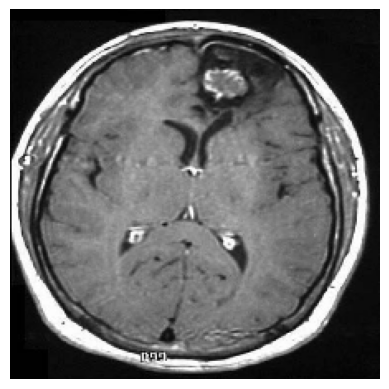

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

img_name = os.listdir('/content/dataset/brain_tumor_dataset/yes')[0]

img_path = os.path.join(
    '/content/dataset/brain_tumor_dataset/yes',
    img_name
)

img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img, (224,224))

img_array = np.expand_dims(img/255.0, axis=0)

plt.imshow(img)
plt.axis('off')
plt.show()

MobileNetV2 Grad-CAM

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Model

# MobileNetV2 base model
base_model = mobilenet_model.layers[0]

# Last conv layer
last_conv_layer = base_model.get_layer("out_relu")

# Grad model
grad_model = Model(
    inputs=base_model.input,
    outputs=[
        last_conv_layer.output,
        base_model.output
    ]
)

with tf.GradientTape() as tape:
    conv_outputs, predictions = grad_model(img_array)
    loss = tf.reduce_mean(predictions)

grads = tape.gradient(loss, conv_outputs)

pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

conv_outputs = conv_outputs[0]

heatmap = tf.reduce_sum(
    conv_outputs * pooled_grads,
    axis=-1
)

heatmap = np.maximum(heatmap, 0)
heatmap = heatmap / (np.max(heatmap) + 1e-8)

Display Heatmap

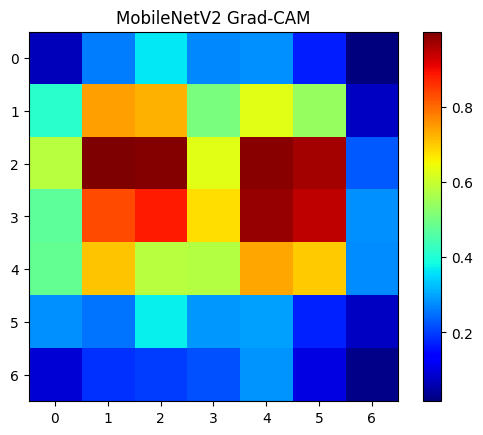

In [ ]:
plt.imshow(heatmap, cmap='jet')
plt.colorbar()
plt.title("MobileNetV2 Grad-CAM")
plt.show()

Overlay

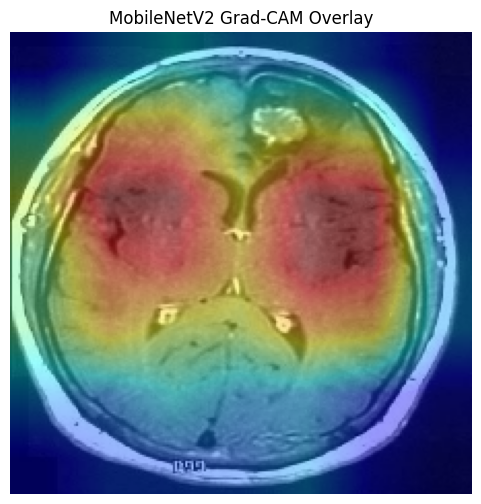

In [ ]:
heatmap = cv2.resize(heatmap, (224,224))

heatmap = np.uint8(255 * heatmap)

heatmap = cv2.applyColorMap(
    heatmap,
    cv2.COLORMAP_JET
)

overlay = cv2.addWeighted(
    cv2.cvtColor(img, cv2.COLOR_RGB2BGR),
    0.6,
    heatmap,
    0.4,
    0
)

plt.figure(figsize=(6,6))
plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title("MobileNetV2 Grad-CAM Overlay")
plt.show()